In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [4]:
!unzip /content/Train.zip

Archive:  /content/Train.zip
   creating: Train/
   creating: Train/Bad/
  inflating: Train/Bad/green (1).png  
  inflating: Train/Bad/green (10).png  
  inflating: Train/Bad/green (100).png  
  inflating: Train/Bad/green (101).png  
  inflating: Train/Bad/green (102).png  
  inflating: Train/Bad/green (103).png  
  inflating: Train/Bad/green (104).png  
  inflating: Train/Bad/green (105).png  
  inflating: Train/Bad/green (106).png  
  inflating: Train/Bad/green (107).png  
  inflating: Train/Bad/green (108).png  
  inflating: Train/Bad/green (109).png  
  inflating: Train/Bad/green (11).png  
  inflating: Train/Bad/green (110).png  
  inflating: Train/Bad/green (111).png  
  inflating: Train/Bad/green (112).png  
  inflating: Train/Bad/green (113).png  
  inflating: Train/Bad/green (114).png  
  inflating: Train/Bad/green (115).png  
  inflating: Train/Bad/green (116).png  
  inflating: Train/Bad/green (117).png  
  inflating: Train/Bad/green (118).png  
  inflating: Train/Bad/green 

In [3]:
!
!file /content/Train.zip

/content/Train.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [6]:
import os

# Adjust these paths if your folder names are different
base_dir = 'Train' # Or whatever you named the unzipped folder
train_dir = base_dir # Corrected: 'Good' and 'Bad' are directly under 'Train'

print('Total Good Beans:', len(os.listdir(os.path.join(train_dir, 'Good'))))
print('Total Bad Beans:', len(os.listdir(os.path.join(train_dir, 'Bad'))))

Total Good Beans: 600
Total Bad Beans: 600


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# This is the "Rules of the Conveyor Belt"
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalization: pixels 0-255 become 0.0-1.0
    rotation_range=20,          # Random rotation
    brightness_range=[0.7, 1.3], # FIX FOR BUG #01: Simulates different lighting
    horizontal_flip=True,       # Flip images
    validation_split=0.2        # Reserve 20% for the 'Final Exam' (Validation)
)

# This actually "grabs" the images from the folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),     # Resize all images to 224x224 for MobileNetV2
    batch_size=32,              # Feed the AI 32 images at a time
    class_mode='binary',        # We only have two categories: Good or Bad
    subset='training'           # This is the training set
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'         # This is the test set
)

Found 960 images belonging to 2 classes.
Found 240 images belonging to 2 classes.


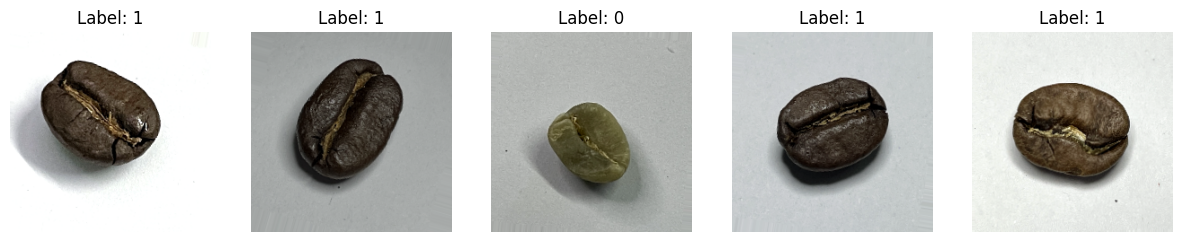

In [8]:
import matplotlib.pyplot as plt

# Grab one "batch" (32 images) from the conveyor belt
images, labels = next(train_generator)

# Show the first 5 images
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.title('Label: ' + str(int(labels[i]))) # 0 usually = Bad, 1 = Good
    plt.axis('off')
plt.show()

In [9]:
# 1. Load MobileNetV2
# 'include_top=False' means we throw away the part that identifies dogs/cats
# 'weights=imagenet' means we keep the 'knowledge' it gained from 1.4M images
base_brain = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. 'Freeze' the brain
# We don't want to change the expert's basic knowledge of shapes and colors yet
base_brain.trainable = False

print("Expert brain loaded and frozen.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Expert brain loaded and frozen.


In [10]:
model = tf.keras.Sequential([
    base_brain,                    # The pre-trained expert
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid') # Sigmoid turns the result into a 0-1 probability
])

print("Model architecture is ready.")

Model architecture is ready.


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary() # This shows you the "map" of the brain you just built

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# The 'history' variable will store all the scores so we can plot them later
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    verbose=1 # This shows the progress bar
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.8823 - loss: 0.3825 - val_accuracy: 0.9833 - val_loss: 0.1574
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9760 - loss: 0.1730 - val_accuracy: 0.9875 - val_loss: 0.1020
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9740 - loss: 0.1193 - val_accuracy: 0.9833 - val_loss: 0.0758
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9844 - loss: 0.0885 - val_accuracy: 0.9958 - val_loss: 0.0562
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9865 - loss: 0.0745 - val_accuracy: 0.9875 - val_loss: 0.0529
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9865 - loss: 0.0643 - val_accuracy: 0.9917 - val_loss: 0.0469
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9885 - loss: 0.0618 - val_accuracy: 0.9917 - val_loss: 0.0396
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9885 - loss: 0.0512 - val_accuracy: 0.9917 - val_loss:

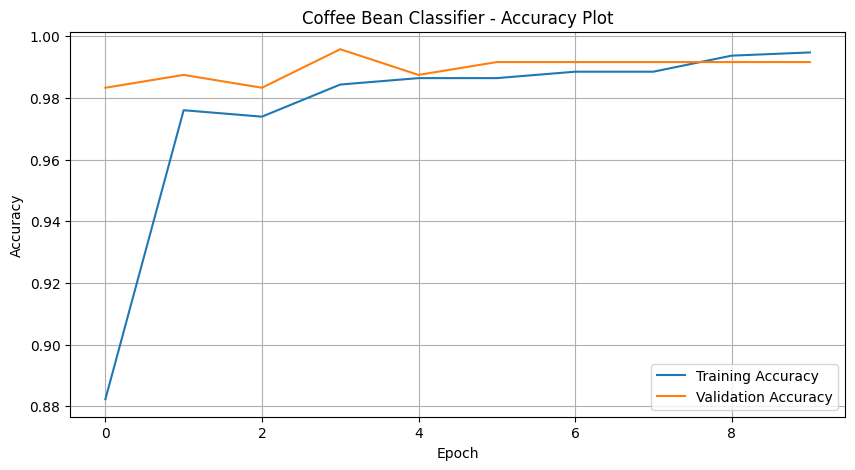

In [13]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Coffee Bean Classifier - Accuracy Plot')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png') # This saves the file for Samuel
plt.show()

In [15]:
model.save('coffee_model_v1.h5')
print("Brain saved as coffee_model_v1.h5. Ready for deployment!")

Brain saved as coffee_model_v1.h5. Ready for deployment!


In [16]:
# 1. Build a 'Simple Brain' from scratch (No expert help)
simple_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

simple_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Train it on the same data
print("Training Simple Model for comparison...")
simple_history = simple_model.fit(train_generator, epochs=5, validation_data=val_generator)

# 3. Save the score for Samuel
print(f"Simple Model Final Accuracy: {simple_history.history['val_accuracy'][-1]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Simple Model for comparison...
Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7500 - loss: 0.9316 - val_accuracy: 1.0000 - val_loss: 0.0463
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9792 - loss: 0.0859 - val_accuracy: 1.0000 - val_loss: 0.0280
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9833 - loss: 0.0618 - val_accuracy: 1.0000 - val_loss: 0.0189
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9885 - loss: 0.0413 - val_accuracy: 1.0000 - val_loss: 0.0292
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9948 - loss: 0.0263 - val_accuracy: 0.9917 - val_loss: 0.0309
Simple Model Final Accuracy: 0.99
